In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parámetros
N = 100       # Total de estampas diferentes
S = 7         # Estampas por sobre
R = 10000     # Número de simulaciones
UMBRAL = 30   # Umbral para probabilidad de necesitar más de 30 sobres

np.random.seed(2026)

In [ ]:
# Simulación
sobres_necesarios = np.zeros(R, dtype=int)
repetidas_totales = np.zeros(R, dtype=int)

for i in range(R):
    coleccion = np.zeros(N, dtype=bool)
    sobres = 0
    repetidas = 0

    while coleccion.sum() < N:
        nuevas = np.random.choice(N, size=S, replace=False)
        sobres += 1
        for est in nuevas:
            if coleccion[est]:
                repetidas += 1
            else:
                coleccion[est] = True

    sobres_necesarios[i] = sobres
    repetidas_totales[i] = repetidas

In [ ]:
# Resultados
media_sobres = np.mean(sobres_necesarios)
std_sobres = np.std(sobres_necesarios)
media_rep = np.mean(repetidas_totales)
std_rep = np.std(repetidas_totales)
prob_mas30 = np.mean(sobres_necesarios > UMBRAL)

In [ ]:
# Valor teórico
H_N = np.sum(1 / np.arange(1, N + 1))
E_teorico = (N / S) * H_N

print("=" * 50)
print("RESULTADOS ETAPA 1")
print("=" * 50)
print(f"Media de sobres necesarios:       {media_sobres:.4f}")
print(f"Desviación estándar de sobres:    {std_sobres:.4f}")
print(f"Media de estampas repetidas:      {media_rep:.4f}")
print(f"Desviación estándar repetidas:    {std_rep:.4f}")
print(f"P(sobres > {UMBRAL}):                {prob_mas30:.4f}")
print(f"Valor teórico E[sobres]:          {E_teorico:.4f}")
print(f"Mínimo teórico de sobres (N/S):   {N/S:.0f}  (sin repetidas)")


RESULTADOS ETAPA 1
Media de sobres necesarios:       72.2456
Desviación estándar de sobres:    17.4715
Media de estampas repetidas:      405.7192
Desviación estándar repetidas:    122.3006
P(sobres > 30):                1.0000
Valor teórico E[sobres]:          74.1054
Mínimo teórico de sobres (N/S):   14  (sin repetidas)


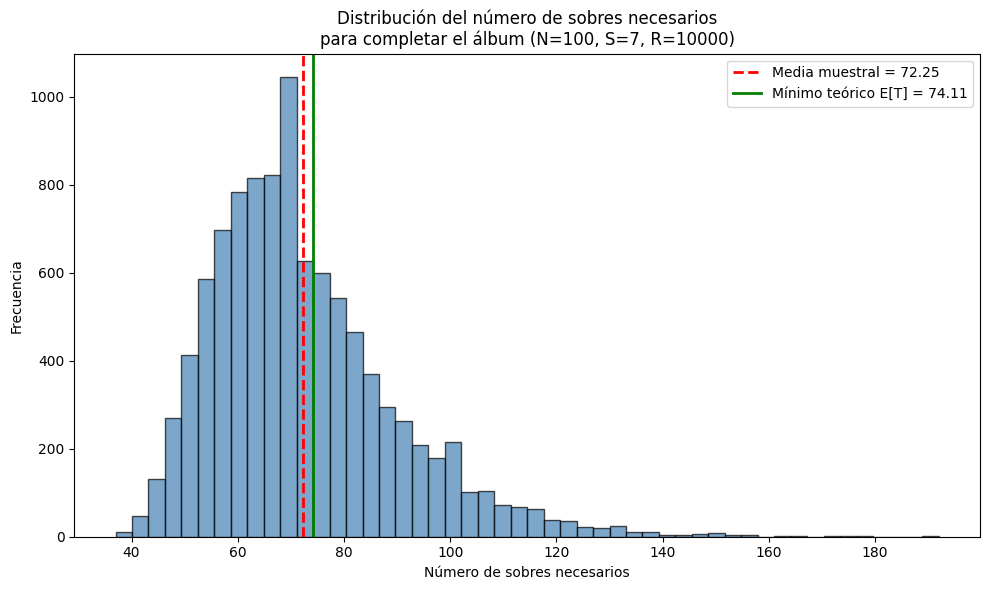

In [ ]:
# Visualización
plt.figure(figsize=(10, 6))
plt.hist(sobres_necesarios, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(media_sobres, color='red', linestyle='--', linewidth=2, label=f'Media muestral = {media_sobres:.2f}')
plt.axvline(E_teorico, color='green', linestyle='-', linewidth=2, label=f'Mínimo teórico E[T] = {E_teorico:.2f}')
plt.xlabel('Número de sobres necesarios')
plt.ylabel('Frecuencia')
plt.title('Distribución del número de sobres necesarios\npara completar el álbum (N=100, S=7, R=10000)')
plt.legend()
plt.tight_layout()
plt.show()

Pregunta 1:

Mínimo de sobres sin repetidas:
⌈100/7⌉ = 15 sobres. No se observa en ninguna simulación (P(sobres > 30) = 1.0000), lo cual es esperado ya que la probabilidad de lograrlo es virtualmente cero.

Pregunta 2:

H₁₀₀ = 5.1874, por lo que E[T] = (100/7) × 5.1874 = 74.1054
Media simulada = 72.2456 error relativo ≈ 2.51%

Pregunta 3: E[repetidas] = E[T]×S − N = 74.1054×7 − 100 = 418.74
Media simulada = 405.72 error relativo ≈ 3.11%

Pregunta 4: CV = 17.47/72.25 = 24.2% Variabilidad alta porque al final de la colección conseguir las últimas estampas requiere muchos sobres (cola derecha larga), haciendo el proceso muy impredecible entre simulaciones.